In [ ]:
# APEX-seq structure information 


In [10]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from statannot import add_stat_annotation 
from Bio import SeqIO
from sklearn import metrics 

In [ ]:
## 1. Extend Figure 5a-5c --- --- 
### 1_1. Extend Fig5a --- --- 
### 1_2. Extend Fig5b --- --- 
### 1_3. Extend Fig5c --- --- 

In [ ]:
### 1_1. Extend Fig5a --- --- 

(16569, 29)
(15863, 29)
(16569, 29)
(15146, 29)
G_Label v.s. G_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=9.358e-66 U_stat=2.712e+06
U_Label v.s. U_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=3.902e-64 U_stat=8.954e+06
A_Label v.s. A_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.181e-214 U_stat=1.550e+07
C_Label v.s. C_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=0.000e+00 U_stat=1.722e+07
                mod_rate
Sequence group          
A        Ctrl   0.000155
         Label  0.000257
C        Ctrl   0.000117
         Label  0.000296
G        Ctrl   0.000136
         Label  0.000317
N        Ctrl   0.000586
         Label  0.001296
U        Ctrl   0.000213
         Label  0.000341


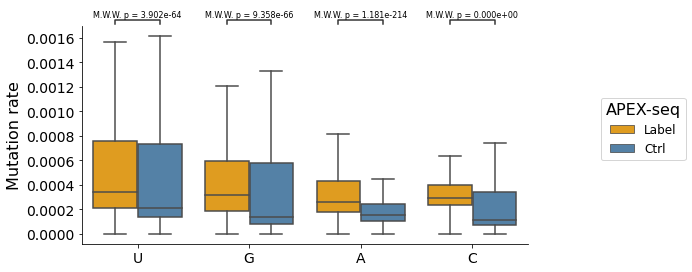

In [11]:
dir = "./Data/"
apex = pd.read_csv(dir+'APEX-seq_mito_NC_012920.1_Homo_sapiens_mitochondrion_complete_genome_profile.txt',sep='\t')

apex_label = apex[apex['Modified_effective_depth'] >=5000]
print(apex.shape)
print(apex_label.shape)
apex_label = apex_label[['Nucleotide','Sequence','Modified_rate']]
apex_label.columns=['Nucleotide','Sequence','mod_rate']
apex_label['group'] = 'Label'

apex_ctrl = apex[apex['Untreated_effective_depth'] >=5000]
print(apex.shape)
print(apex_ctrl.shape)
apex_ctrl = apex_ctrl[['Nucleotide','Sequence','Untreated_rate']]
apex_ctrl.columns=['Nucleotide','Sequence','mod_rate']
apex_ctrl['group'] = 'Ctrl'

apex_flt = pd.concat([apex_label,apex_ctrl])
dplot = apex_flt

dplot.to_csv('./Data/'+'source_data_Efig5a.csv',sep=',')

### plots ---

plt.figure(figsize=(8,4))

order = ['U','G', 'A',  'C']
my_pal = {'Label': "orange", 'Ctrl': "steelblue"}
ax = sns.boxplot(data=dplot, x='Sequence',y='mod_rate', hue='group',showfliers = False,order = order, palette = my_pal)     #palette = my_pal

plt.title(' ',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Mutation rate',fontsize = 16)
plt.xticks(fontsize = 14) 
plt.yticks(fontsize = 14) 
legend=plt.legend(loc='best', title='APEX-seq',bbox_to_anchor=(1.15, 0.7),prop={'size': 12})
legend.get_title().set_fontsize('16') 
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data=dplot, x='Sequence',y='mod_rate', hue='group', order=order, 
                    box_pairs = [(("U", 'Label'), ("U", 'Ctrl')),
                                 (("A", 'Label'), ("A", 'Ctrl')),
                                 (("C", 'Label'), ("C", 'Ctrl')),
                                 (("G", 'Label'), ("G", 'Ctrl'))
                                ],
                    test="Mann-Whitney", text_format='full', loc='outside', line_offset_to_box=0.01, verbose=1,fontsize=8)  #line_offset_to_box=-0.001,

dir_out = "./Data/"
plt.savefig(dir_out+'Extend_Fig5a_APEX_RNA_mutation_rate_label_vs_Ctrl.pdf',bbox_inches='tight', dpi=300) 

print(dplot.groupby(['Sequence','group']).median()[['mod_rate']])  

In [12]:
print(dplot.groupby(['Sequence','group']).mean()[['mod_rate']]) 

                mod_rate
Sequence group          
A        Ctrl   0.003222
         Label  0.003124
C        Ctrl   0.001314
         Label  0.001903
G        Ctrl   0.003467
         Label  0.003333
N        Ctrl   0.000586
         Label  0.001296
U        Ctrl   0.001505
         Label  0.001399


In [13]:
print(dplot.groupby(["Sequence", "group"]).count())  

                Nucleotide  mod_rate
Sequence group                      
A        Ctrl         4631      4631
         Label        4884      4884
C        Ctrl         4789      4789
         Label        4984      4984
G        Ctrl         1989      1989
         Label        2079      2079
N        Ctrl            1         1
         Label           1         1
U        Ctrl         3736      3736
         Label        3915      3915


In [ ]:
### 1_2. Extend Fig5b --- --- 

In [14]:
def convert_dot(input_file,rna): 
    sequences=[i for i in SeqIO.parse(open(input_file),'fasta')] 
    
    seq_0 = str(sequences[0].seq)
    length = len(seq_0)
    base = seq_0[0:int(length/2)]
    dot = seq_0[int(length/2):int(length)]
    
    base = list(map(lambda i:i, base))
    dot = list(map(lambda i:i, dot))
    strand = list(map(lambda i: 1 if i == "." else 0, dot))
    Nucleotide = range(1,len(strand)+1)
    
    bench = pd.DataFrame(list(zip(base,dot,strand,Nucleotide)),
              columns=['base','dot','strand','Position2'])
    bench.to_csv('./Data/'+rna+'_base_dot_strand.csv',sep='\t')
    
    return bench 

In [15]:
#### A. input 
dir = "./Data/"
apex = pd.read_csv(dir+'APEX-seq_mito_NC_012920.1_Homo_sapiens_mitochondrion_complete_genome_profile.txt',sep='\t')
cox1= apex[(apex['Nucleotide']>=5900) & (apex['Nucleotide']<=7517)]
cox1=cox1[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
cox1 = cox1[(cox1['Modified_effective_depth']>=5000) & (cox1['Untreated_effective_depth']>=5000)]

print(cox1.shape)
cox1['Nucleotide']=cox1['Nucleotide']-5899
cox1['Position2'] =cox1['Nucleotide']

#### B. bench 
dir_bench = './Data/bench/'
bench = convert_dot(dir_bench+'bench_positive_COX1_1_1618_162.dot','COX1')

#### C. combine 
df = pd.merge(cox1,bench, how='left',on=['Position2','Position2'])

#### D. SS and DS regions
dplot=df
tmp1 = dplot[dplot['strand'] == 1]
tmp1['region'] = 'SS'
tmp2 = dplot[dplot['strand'] == 0]
tmp2['region'] = 'DS'
dplot = pd.concat([tmp1,tmp2], ignore_index=True)
dplott = dplot[(dplot['base'] =='T') | (dplot['base'] =='U')] 

dplott.to_csv('./Data/'+'source_data_Efig5b.csv',sep=',')

(1606, 8)


/tmp/ipykernel_129836/1094510121.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp1['region'] = 'SS'
/tmp/ipykernel_129836/1094510121.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp2['region'] = 'DS'


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


SS v.s. DS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=4.110e-01 U_stat=1.619e+04


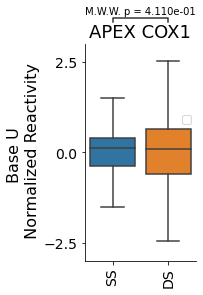

In [16]:
#### plot 

plt.figure(figsize=(2,4))

order = ['SS', 'DS']
ax = sns.boxplot(data=dplott, x='region',y='Norm_profile', showfliers = False,order = order, dodge = False) 

plt.title('APEX COX1',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Base U \n Normalized Reactivity',fontsize = 16)
plt.ylim(-3,3)
plt.xticks(fontsize = 14,rotation=90) 
plt.yticks([-2.5,0,2.5],fontsize = 14) 
plt.legend(loc='best', bbox_to_anchor=(1.01, 0.7),prop={'size': 12})
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data = dplott, x = dplott['region'], y = dplott['Norm_profile'], order=order, 
                    box_pairs = [('SS','DS')],
                    test="Mann-Whitney", text_format='full', loc='outside', line_offset_to_box=0.1, verbose=3)  #line_offset_to_box=-0.001,

dir_out = "./Data/"
plt.savefig(dir_out+'Extend_Fig5b_APEX_COX1_baseU_react_SS_vs_DS.pdf',bbox_inches='tight', dpi=300) 

In [17]:
print(dplott.groupby(["region"]).count())  

        Nucleotide  Sequence  Modified_effective_depth  \
region                                                   
DS              95        95                        95   
SS             324       324                       324   

        Untreated_effective_depth  Modified_rate  Untreated_rate  \
region                                                             
DS                             95             95              95   
SS                            324            324             324   

        Reactivity_profile  Norm_profile  Position2  base  dot  strand  
region                                                                  
DS                      95            95         95    95   95      95  
SS                     324           323        324   324  324     324  


In [ ]:
### 1_3. Extend Fig5c --- --- ---

In [8]:
def convert_dot(input_file,rna): 
    sequences=[i for i in SeqIO.parse(open(input_file),'fasta')] 
    
    seq_0 = str(sequences[0].seq)
    length = len(seq_0)
    base = seq_0[0:int(length/2)]
    dot = seq_0[int(length/2):int(length)]
    
    base = list(map(lambda i:i, base))
    dot = list(map(lambda i:i, dot))
    strand = list(map(lambda i: 1 if i == "." else 0, dot))
    Nucleotide = range(1,len(strand)+1)
    
    bench = pd.DataFrame(list(zip(base,dot,strand,Nucleotide)),
              columns=['base','dot','strand','Position2'])
    bench.to_csv('./Data/'+rna+'_base_dot_strand.csv',sep='\t')
    
    return bench 

(1618, 8)
0.5261208576998051


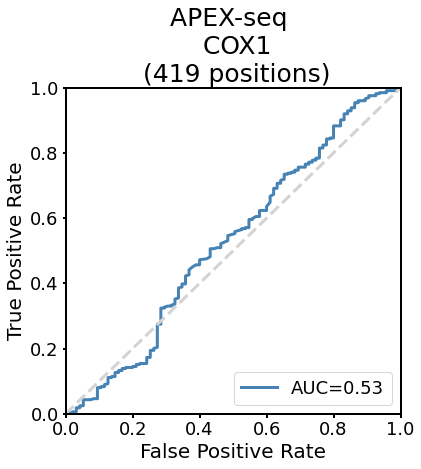

In [9]:
#### A. input 

dir = "./Data/"
apex = pd.read_csv(dir+'APEX-seq_mito_NC_012920.1_Homo_sapiens_mitochondrion_complete_genome_profile.txt',sep='\t')
cox1= apex[(apex['Nucleotide']>=5900) & (apex['Nucleotide']<=7517)]
cox1=cox1[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
print(cox1.shape)
cox1 = cox1[(cox1['Modified_effective_depth']>=5000) & (cox1['Untreated_effective_depth']>=5000)]


cox1['Nucleotide']=cox1['Nucleotide']-5899
cox1['Position2'] =cox1['Nucleotide']

#### B. bench 

dir_bench = './Data/bench/'
bench = convert_dot(dir_bench+'bench_positive_COX1_1_1618_162.dot','COX1')

#### C. combine 
df = pd.merge(cox1,bench, how='left',on=['Position2','Position2'])
flt=df[(df['base']=='T') | (df['base']=='U')]

flt.to_csv('./Data/'+'source_data_Efig5c.csv',sep=',')

## plot --------------------------

fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile, pos_label=1)
roc_auc_1 = metrics.auc(fpr_1, tpr_1)
print(roc_auc_1)

fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
    ax.tick_params(width = 2)
    
plt.title('APEX-seq \n COX1'+'\n ('+str(flt.shape[0])+' positions)', fontsize = 25)
plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)

plt.legend(loc = 'lower right', fontsize = 18)
plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize = 20)
plt.xlabel('False Positive Rate', fontsize = 20)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)

dir_out = "./Data/"
plt.savefig(dir_out+'Extend_Fig5c_APEX_COX1_baseU_AUROC.pdf',bbox_inches='tight', dpi=300) 